# Projet IA Travel Planning — Version sans enrichissement


## Note de version

Cette version entraîne les modèles uniquement avec le dataset nettoyé et les variables créées en feature engineering.

L'enrichissement métier par destination est volontairement exclu afin d'évaluer le signal disponible dans le dataset actuel.


## 0. Contexte et perimetre

Une agence de voyages haut de gamme souhaite concevoir une solution IA capable de personnaliser la planification de sejours.

D'apres le cas d'usage, le modele principal doit aider a la planification avant le depart. Les variables utilisees en entree doivent donc etre disponibles au moment de la recommandation ou de l'organisation du voyage.

Les variables suivantes sont exclues du modele principal car elles sont connues pendant ou apres le sejour :

- `imprevus` ;
- `reorganisation_necessaire` ;
- `respect_budget` ;
- `retour_client`.

Cette decision evite une fuite de donnees : le modele ne doit pas apprendre avec des informations futures.

Ces variables peuvent rester utiles dans une analyse retrospective ou dans des modeles secondaires, par exemple pour expliquer les causes d'insatisfaction ou predire le risque d'imprevu.

## 1. Datasheet synthétique

| Élément | Description |
| --- | --- |
| Fichier | `data/Examen_travel_planning_dataset.csv` |
| Format | CSV |
| Volume attendu | Environ 1500 séjours |
| Domaine | Planification de voyages haut de gamme |
| Nature des données | Données synthétiques et anonymisées |
| Cible IA principale | `satisfaction_client` |
| Problème ML | Classification multi-classes de satisfaction |

Le fichier contient des informations sur le profil client, le budget, la destination, la saison, la durée, l'hébergement, le vol, la météo prévue, l'activité principale et les résultats observés après séjour.

## 2. Configuration

Cette section importe les bibliothèques nécessaires et limite le nombre de threads pour réduire la consommation mémoire sur une machine disposant de peu de RAM.

In [93]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)
sns.set_theme(style="whitegrid")

## 3. Chargement du dataset brut

Le dataset brut est conservé dans `df_raw`. Les traitements de préparation seront appliqués sur une copie afin de garder une référence intacte aux données originales.

In [94]:
filename = "Examen_travel_planning_dataset.csv"
candidate_paths = [
    Path("data") / filename,
    Path("data/raw") / filename,
    Path("../data") / filename,
    Path("../data/raw") / filename,
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(f"Fichier introuvable : {filename}")

df_raw = pd.read_csv(data_path)

print(f"Fichier chargé : {data_path}")
print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
display(df_raw.head())

Fichier chargé : ..\data\Examen_travel_planning_dataset.csv
Dimensions : 1500 lignes x 15 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


In [95]:
# Contr?le des valeurs n?gatives dans les colonnes num?riques du dataset brut
colonnes_numeriques = ["budget_total", "duree_jours", "prix_vol"]

valeurs_negatives = pd.DataFrame({
    "colonne": colonnes_numeriques,
    "nb_valeurs_negatives": [
        int((df_raw[col] < 0).sum()) for col in colonnes_numeriques
    ],
    "valeur_minimale": [
        df_raw[col].min() for col in colonnes_numeriques
    ],
})

display(valeurs_negatives)


,colonne,nb_valeurs_negatives,valeur_minimale
0,budget_total,0,380.0
1,duree_jours,0,2.0
2,prix_vol,0,35.0


## 4. Exploration rapide du brut

Cette exploration vérifie la structure du fichier avant toute modification : dimensions, types, valeurs manquantes et doublons.

In [96]:
resume_brut = pd.DataFrame({
    "type": df_raw.dtypes.astype(str),
    "valeurs_manquantes": df_raw.isna().sum(),
    "pourcentage_manquant": (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    "valeurs_uniques": df_raw.nunique(dropna=True),
})

display(resume_brut)

print("Doublons exacts :", int(df_raw.duplicated().sum()))
print("Doublons trip_id :", int(df_raw["trip_id"].duplicated().sum()))

,type,valeurs_manquantes,pourcentage_manquant,valeurs_uniques
trip_id,int64,0,0.00,1500
client_type,object,0,0.00,5
budget_total,float64,40,2.67,1419
destination,object,0,0.00,8
saison,object,0,0.00,4
duree_jours,int64,0,0.00,23
type_hebergement,object,36,2.40,4
prix_vol,float64,53,3.53,1429
meteo_prevue,object,39,2.60,4
activite_principale,object,48,3.20,5


Doublons exacts : 0
Doublons trip_id : 0


,valeurs_manquantes,pourcentage
prix_vol,53,3.53
imprevus,53,3.53
activite_principale,48,3.20
budget_total,40,2.67
meteo_prevue,39,2.60
type_hebergement,36,2.40
satisfaction_client,25,1.67
retour_client,25,1.67


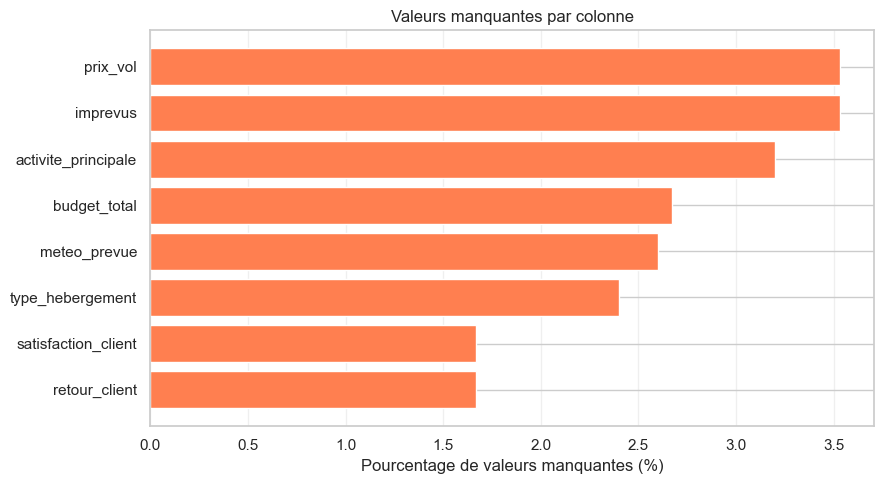

In [97]:
missing_summary = (
    df_raw.isna().sum()
    .to_frame("valeurs_manquantes")
)
missing_summary["pourcentage"] = (missing_summary["valeurs_manquantes"] / len(df_raw) * 100).round(2)
missing_summary = missing_summary[missing_summary["valeurs_manquantes"] > 0].sort_values("valeurs_manquantes", ascending=False)

display(missing_summary)

if not missing_summary.empty:
    plt.figure(figsize=(9, 5))
    plt.barh(missing_summary.index[::-1], missing_summary["pourcentage"][::-1], color="coral")
    plt.xlabel("Pourcentage de valeurs manquantes (%)")
    plt.title("Valeurs manquantes par colonne")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Analyse métier de cohérence du dataset brut

Cette section reprend l'analyse métier détaillée du notebook `analyse_métier.ipynb`.

Elle est placée avant le nettoyage pour distinguer :

- les incohérences critiques à traiter avant la modélisation ;
- les points de vigilance à documenter ;
- les variables à exclure du modèle principal pour éviter la fuite de données.


In [98]:
# Fonctions utilitaires utilisées dans tout le notebook

def normaliser_texte(serie):
    """Standardise les textes pour faciliter les comparaisons métier."""
    return serie.fillna("").astype(str).str.strip().str.lower()


def afficher_cas(df_cas, colonnes=None, n=10):
    """Affiche le nombre de cas détectés puis un échantillon lisible."""
    print(f"Nombre de cas détectés : {len(df_cas)}")
    if len(df_cas) == 0:
        print("Aucun cas à afficher.")
        return

    if colonnes is not None:
        display(df_cas[colonnes].head(n))
    else:
        display(df_cas.head(n))


colonnes_principales = [
    "trip_id", "client_type", "budget_total", "destination", "saison",
    "duree_jours", "type_hebergement", "prix_vol", "meteo_prevue",
    "activite_principale", "satisfaction_client", "imprevus",
    "reorganisation_necessaire", "respect_budget"
]

### 5.1. Unicité des séjours

### Observation métier

Chaque ligne représente un séjour passé. La colonne `trip_id` doit donc identifier un séjour unique.

Un doublon sur `trip_id` pourrait fausser l'analyse car un même séjour serait compté plusieurs fois.

In [99]:
doublons_trip_id = df_raw[df_raw["trip_id"].duplicated(keep=False)].copy()
doublons_lignes = df_raw[df_raw.duplicated(keep=False)].copy()

print("Doublons sur trip_id :")
afficher_cas(doublons_trip_id, colonnes_principales)

print("\nDoublons exacts sur toutes les colonnes :")
afficher_cas(doublons_lignes, colonnes_principales)

Doublons sur trip_id :
Nombre de cas détectés : 0
Aucun cas à afficher.

Doublons exacts sur toutes les colonnes :
Nombre de cas détectés : 0
Aucun cas à afficher.


### 5.2. Cohérence de la satisfaction client

### Observation métier

Le cahier des charges indique que `satisfaction_client` est un score de 1 à 5.

Les valeurs inférieures à 1, supérieures à 5 ou manquantes sont donc incohérentes avec la définition officielle de la variable.

Ces cas doivent être corrigés, exclus ou documentés avant d'utiliser `satisfaction_client` comme cible IA.

In [100]:
satisfaction_invalide = df_raw[
    df_raw["satisfaction_client"].isna()
    | ~df_raw["satisfaction_client"].between(1, 5)
].copy()

afficher_cas(
    satisfaction_invalide,
    ["trip_id", "client_type", "destination", "satisfaction_client", "imprevus", "retour_client"]
)

Nombre de cas détectés : 30


,trip_id,client_type,destination,satisfaction_client,imprevus,retour_client
765,766,couple,Bali,NaN,annulation,Une expérience inoubliable.
771,772,solo,Tokyo,NaN,bagages,À éviter.
778,779,couple,Rome,NaN,annulation,Déçu par l'organisation.
800,801,couple,Paris,6.0,aucun,Très bon rapport qualité-prix.
801,802,famille,Dubaï,NaN,aucun,Une expérience inoubliable.
811,812,solo,Rome,6.0,aucun,"Très satisfait, je recommande."
812,813,solo,Bali,0.0,retard_vol,À éviter.
826,827,couple,Sydney,NaN,météo,Déçu par l'organisation.
835,836,famille,Dubaï,NaN,météo,Excellent séjour.
858,859,famille,Paris,NaN,retard_vol,Très mauvaise expérience.


### 5.3. Prix du vol supérieur au budget total

### Observation métier

Le `budget_total` représente le budget global du séjour.

Si `prix_vol > budget_total`, le coût du vol dépasse déjà le budget disponible. C'est une incohérence forte ou un séjour impossible à financer sans dépassement.

Le cas est encore plus problématique si `respect_budget = 1`, car cela indique que le budget aurait été respecté malgré un vol supérieur au budget total.

In [101]:
vol_superieur_budget = df_raw[
    df_raw["prix_vol"].notna()
    & df_raw["budget_total"].notna()
    & (df_raw["prix_vol"] > df_raw["budget_total"])
].copy()

vol_superieur_budget["ecart_vol_budget"] = (
    vol_superieur_budget["prix_vol"] - vol_superieur_budget["budget_total"]
).round(2)

print("Tous les cas où le prix du vol dépasse le budget total :")
afficher_cas(
    vol_superieur_budget.sort_values("ecart_vol_budget", ascending=False),
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

print("\nCas contradictoires : prix_vol > budget_total ET respect_budget = 1")
vol_superieur_budget_respecte = vol_superieur_budget[vol_superieur_budget["respect_budget"] == 1]
afficher_cas(
    vol_superieur_budget_respecte,
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

Tous les cas où le prix du vol dépasse le budget total :
Nombre de cas détectés : 52


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
825,826,couple,Rome,500.00,4500.00,4000.00,0
1388,1389,business,Rome,1052.28,4500.00,3447.72,0
1434,1435,business,Paris,500.00,1554.63,1054.63,0
1384,1385,famille,Lisbonne,4152.93,5200.00,1047.07,1
902,903,famille,Rome,500.00,1535.25,1035.25,0
1413,1414,famille,Tokyo,637.34,1593.89,956.55,0
1144,1145,famille,Dubaï,500.00,1443.55,943.55,0
948,949,couple,New York,500.00,1432.13,932.13,0
1402,1403,business,New York,500.00,1426.89,926.89,0
1206,1207,senior,Lisbonne,500.00,1352.70,852.70,0



Cas contradictoires : prix_vol > budget_total ET respect_budget = 1
Nombre de cas détectés : 5


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
7,8,couple,Rome,1173.19,1694.67,521.48,1
216,217,business,Rome,1147.25,1438.08,290.83,1
230,231,business,Dubaï,1388.56,1444.72,56.16,1
887,888,solo,Dubaï,380.00,1023.17,643.17,1
1384,1385,famille,Lisbonne,4152.93,5200.00,1047.07,1


### 5.4. Cohérence entre client business et activité principale

### Observation métier

Un client `business` peut avoir une activité principale `business`, mais ce n'est pas obligatoire : il peut aussi prolonger son séjour avec de la culture, de la gastronomie ou une activité de loisir.

Ce contrôle n'est donc pas une erreur automatique. C'est un point de vigilance pour vérifier si le dataset décrit bien le comportement attendu des voyageurs professionnels.

In [102]:
client_type_norm = normaliser_texte(df_raw["client_type"])
activite_norm = normaliser_texte(df_raw["activite_principale"])

business_activite_non_business = df_raw[
    (client_type_norm == "business")
    & (activite_norm != "business")
    & (activite_norm != "")
].copy()

non_business_activite_business = df_raw[
    (client_type_norm != "business")
    & (client_type_norm != "")
    & (activite_norm == "business")
].copy()

print("Clients business avec une activité principale non-business :")
afficher_cas(
    business_activite_non_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

print("\nClients non-business avec une activité principale business :")
afficher_cas(
    non_business_activite_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

Clients business avec une activité principale non-business :
Nombre de cas détectés : 200


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
1,2,business,Rome,printemps,randonnée,3288.27,4.0
14,15,business,New York,été,randonnée,12985.57,4.0
19,20,business,Tokyo,printemps,plage,10416.72,3.0
27,28,business,Lisbonne,été,culture,10572.54,5.0
29,30,business,Dubaï,été,culture,2403.24,4.0
34,35,business,Bali,hiver,gastronomie,7427.80,1.0
37,38,business,New York,printemps,plage,13023.12,5.0
40,41,business,Tokyo,été,culture,5227.96,2.0
41,42,business,Tokyo,été,randonnée,5142.10,5.0
44,45,business,Tokyo,été,culture,4100.91,3.0



Clients non-business avec une activité principale business :
Nombre de cas détectés : 122


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
10,11,senior,Bali,automne,business,12845.33,5.0
15,16,solo,Rome,automne,business,6125.88,1.0
16,17,senior,New York,hiver,business,8193.32,2.0
20,21,famille,Bali,automne,business,8186.44,2.0
23,24,solo,Dubaï,automne,business,13391.63,5.0
25,26,couple,Lisbonne,hiver,business,954.98,1.0
42,43,solo,New York,printemps,business,13696.57,2.0
47,48,couple,Lisbonne,hiver,business,9297.44,5.0
71,72,solo,Sydney,hiver,business,2187.78,3.0
129,130,solo,Tokyo,hiver,business,4161.07,3.0


### 5.5. Activités extérieures et météo risquée

### Observation métier

L'activité `randonnée` est sensible à la météo.

Si la météo prévue est `pluie` ou `variable`, le séjour peut nécessiter une alternative ou un plan de réorganisation.

Ce n'est pas forcément une erreur, mais c'est une information importante pour l'anticipation des imprévus.

In [103]:
meteo_norm = normaliser_texte(df_raw["meteo_prevue"])
activites_exterieures = ["randonnée", "randonnee"]
meteos_risquees = ["pluie", "variable"]

activites_meteo_risque = df_raw[
    activite_norm.isin(activites_exterieures)
    & meteo_norm.isin(meteos_risquees)
].copy()

afficher_cas(
    activites_meteo_risque,
    ["trip_id", "destination", "saison", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

Nombre de cas détectés : 75


,trip_id,destination,saison,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
1,2,Rome,printemps,variable,randonnée,aucun,0,4.0
7,8,Rome,été,pluie,randonnée,annulation,1,2.0
9,10,New York,automne,variable,randonnée,météo,1,1.0
14,15,New York,été,pluie,randonnée,retard_vol,1,4.0
32,33,Dubaï,printemps,variable,randonnée,bagages,1,1.0
38,39,Lisbonne,été,pluie,randonnée,retard_vol,1,1.0
51,52,Paris,printemps,variable,randonnée,bagages,1,2.0
54,55,Dubaï,automne,variable,randonnée,retard_vol,1,2.0
157,158,Paris,printemps,variable,randonnée,aucun,0,3.0
169,170,Lisbonne,hiver,variable,randonnée,aucun,0,1.0


### 5.6. Cohérence entre imprévus et réorganisation

### Observation métier

La variable `reorganisation_necessaire` doit normalement être liée aux imprévus.

Deux situations sont à contrôler :

1. `imprevus = aucun` mais `reorganisation_necessaire = 1` : cas suspect, car il y a une réorganisation sans imprévu déclaré ;
2. `imprevus != aucun` mais `reorganisation_necessaire = 0` : cas possible si l'imprévu est mineur, mais à vérifier.

In [104]:
imprevus_norm = normaliser_texte(df_raw["imprevus"])

aucun_imprevu_mais_reorganisation = df_raw[
    (imprevus_norm == "aucun")
    & (df_raw["reorganisation_necessaire"] == 1)
].copy()

imprevu_sans_reorganisation = df_raw[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & (df_raw["reorganisation_necessaire"] == 0)
].copy()

print("Aucun imprévu déclaré mais réorganisation nécessaire :")
afficher_cas(
    aucun_imprevu_mais_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

print("\nImprévu déclaré mais aucune réorganisation :")
afficher_cas(
    imprevu_sans_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

Aucun imprévu déclaré mais réorganisation nécessaire :
Nombre de cas détectés : 19


,trip_id,destination,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
78,79,Bali,ensoleillé,gastronomie,aucun,1,3.0
135,136,Bali,ensoleillé,plage,aucun,1,3.0
136,137,New York,nuageux,business,aucun,1,4.0
262,263,Lisbonne,pluie,gastronomie,aucun,1,3.0
363,364,Bali,ensoleillé,gastronomie,aucun,1,5.0
395,396,New York,ensoleillé,randonnée,aucun,1,2.0
417,418,Rome,pluie,business,aucun,1,2.0
473,474,Dubaï,pluie,business,aucun,1,2.0
490,491,Lisbonne,nuageux,culture,aucun,1,5.0
496,497,Paris,pluie,plage,aucun,1,2.0



Imprévu déclaré mais aucune réorganisation :
Nombre de cas détectés : 335


,trip_id,destination,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
63,64,Lisbonne,ensoleillé,plage,météo,0,3.0
66,67,Rome,ensoleillé,business,météo,0,4.0
69,70,Tokyo,ensoleillé,randonnée,retard_vol,0,2.0
71,72,Sydney,variable,business,météo,0,3.0
72,73,Lisbonne,ensoleillé,gastronomie,retard_vol,0,1.0
79,80,Tokyo,nuageux,randonnée,bagages,0,2.0
81,82,New York,variable,gastronomie,météo,0,3.0
86,87,Dubaï,pluie,culture,retard_vol,0,1.0
90,91,Paris,ensoleillé,culture,annulation,0,3.0
91,92,Bali,variable,culture,retard_vol,0,4.0


### 5.7. Imprévus et satisfaction faible

### Observation métier

Un imprévu peut réduire la satisfaction client.

Les cas où `imprevus != aucun` et `satisfaction_client <= 2` sont cohérents métier, mais importants pour comprendre les facteurs d'insatisfaction.

Ils peuvent alimenter l'analyse explicative, mais il faut éviter d'utiliser les imprévus comme variable d'entrée si l'objectif est de prédire la satisfaction avant le départ.

In [105]:
imprevus_satisfaction_faible = df_raw[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & df_raw["satisfaction_client"].notna()
    & (df_raw["satisfaction_client"] <= 2)
].copy()

afficher_cas(
    imprevus_satisfaction_faible,
    ["trip_id", "client_type", "destination", "imprevus", "reorganisation_necessaire", "respect_budget", "satisfaction_client", "retour_client"]
)

Nombre de cas détectés : 573


,trip_id,client_type,destination,imprevus,reorganisation_necessaire,respect_budget,satisfaction_client,retour_client
4,5,solo,Paris,retard_vol,1,1,2.0,Séjour mitigé.
7,8,couple,Rome,annulation,1,1,2.0,Séjour mitigé.
8,9,couple,Paris,annulation,1,0,2.0,Séjour mitigé.
9,10,solo,New York,météo,1,0,1.0,Séjour mitigé.
11,12,senior,Paris,retard_vol,1,0,2.0,Séjour mitigé.
12,13,famille,New York,météo,1,1,1.0,Séjour mitigé.
13,14,solo,Sydney,annulation,1,1,2.0,Séjour mitigé.
22,23,famille,Lisbonne,bagages,1,0,1.0,Séjour mitigé.
25,26,couple,Lisbonne,retard_vol,1,1,1.0,Séjour mitigé.
28,29,solo,Bali,retard_vol,1,0,2.0,Séjour mitigé.


### 5.8. Risque de fuite de donnees pour la modelisation

### Observation metier

Certaines colonnes decrivent le resultat du sejour apres coup :

- `imprevus` ;
- `reorganisation_necessaire` ;
- `respect_budget` ;
- `retour_client`.

Pour le modele principal de prediction de `satisfaction_client` avant depart, ces variables sont exclues de `X`.

Cette decision est coherente avec le cas d'usage : le modele doit aider a planifier le sejour avant sa realisation. Utiliser ces variables reviendrait a apprendre avec des informations futures, ce qui creerait une fuite de donnees.

Ces variables peuvent toutefois etre conservees pour une analyse retrospective ou pour des modeles secondaires, par exemple predire le risque d'imprevu ou le besoin de reorganisation.

In [106]:
colonnes_post_sejour = ["imprevus", "reorganisation_necessaire", "respect_budget", "retour_client", "satisfaction_client"]
display(df_raw[["trip_id", *colonnes_post_sejour]].head(10))

,trip_id,imprevus,reorganisation_necessaire,respect_budget,retour_client,satisfaction_client
0,1,annulation,1,0,Séjour mitigé.,3.0
1,2,aucun,0,1,Excellent séjour.,4.0
2,3,météo,1,1,Excellent séjour.,5.0
3,4,météo,1,1,Séjour mitigé.,3.0
4,5,retard_vol,1,1,Séjour mitigé.,2.0
5,6,météo,1,1,Excellent séjour.,5.0
6,7,météo,1,1,Excellent séjour.,5.0
7,8,annulation,1,1,Séjour mitigé.,2.0
8,9,annulation,1,0,Séjour mitigé.,2.0
9,10,météo,1,0,Séjour mitigé.,1.0


### 5.9. Analyse post-séjour des retours clients

`retour_client` est un texte libre rédigé après le séjour.

Cette variable est utile pour comprendre les causes de satisfaction ou d’insatisfaction, mais elle ne doit pas être utilisée comme variable d’entrée du modèle prédictif principal.

La raison est simple : au moment de planifier un nouveau voyage, l’avis client final n’existe pas encore. L’utiliser dans `X` provoquerait une fuite de données.

On l’analyse donc à part, comme information post-séjour utile pour l’amélioration continue et une future analyse NLP.


In [ ]:
# Analyse descriptive de retour_client
retours_clients = df_raw["retour_client"].fillna("").astype(str).str.strip()

resume_retours_clients = pd.DataFrame({
    "indicateur": [
        "lignes avec retour_client",
        "lignes sans retour_client",
        "avis distincts non vides",
    ],
    "valeur": [
        int((retours_clients != "").sum()),
        int((retours_clients == "").sum()),
        int(df_raw["retour_client"].nunique(dropna=True)),
    ],
})

display(resume_retours_clients)

frequence_retours_clients = (
    df_raw["retour_client"]
    .fillna("retour_absent")
    .value_counts()
    .rename_axis("retour_client")
    .reset_index(name="nombre")
)

frequence_retours_clients["pourcentage"] = (
    frequence_retours_clients["nombre"] / len(df_raw) * 100
).round(2)

display(frequence_retours_clients)


In [ ]:
# Catégorisation simple des retours clients pour analyse post-séjour
def categoriser_retour_client(texte):
    if pd.isna(texte) or str(texte).strip() == "":
        return "absent"

    texte_normalise = str(texte).strip().lower()

    mots_positifs = [
        "excellent",
        "très satisfait",
        "tres satisfait",
        "parfait",
        "inoubliable",
        "bon rapport",
    ]
    mots_negatifs = [
        "déçu",
        "decu",
        "mauvaise",
        "problèmes",
        "problemes",
        "à éviter",
        "a eviter",
        "ne recommande pas",
    ]
    mots_mitiges = [
        "mitigé",
        "mitige",
        "perfectible",
        "peut mieux faire",
        "globalement bien",
        "ensemble satisfaisant",
    ]

    if any(mot in texte_normalise for mot in mots_negatifs):
        return "negatif"
    if any(mot in texte_normalise for mot in mots_positifs):
        return "positif"
    if any(mot in texte_normalise for mot in mots_mitiges):
        return "mitige"

    return "autre"


df_retours_clients = df_raw[["trip_id", "satisfaction_client", "retour_client"]].copy()
df_retours_clients["categorie_retour"] = df_retours_clients["retour_client"].apply(
    categoriser_retour_client
)

# Pour l’analyse de cohérence, on garde uniquement les notes valides de 1 à 5.
df_retours_clients_valides = df_retours_clients[
    df_retours_clients["satisfaction_client"].between(1, 5)
].copy()

synthese_retours_satisfaction = (
    df_retours_clients_valides
    .groupby("categorie_retour", dropna=False)
    .agg(
        nb_sejours=("trip_id", "count"),
        satisfaction_moyenne=("satisfaction_client", "mean"),
        satisfaction_mediane=("satisfaction_client", "median"),
    )
    .round(2)
    .sort_values("satisfaction_moyenne", ascending=False)
)

display(synthese_retours_satisfaction)

table_retour_satisfaction = pd.crosstab(
    df_retours_clients_valides["categorie_retour"],
    df_retours_clients_valides["satisfaction_client"].astype(int),
    dropna=False,
)

display(table_retour_satisfaction)

print("Important : retour_client reste exclu des variables explicatives du modèle principal.")


### 5.10. Synthèse des contrôles

Ce tableau résume les contrôles réalisés et le nombre de cas détectés.

Il sert de base pour décider quoi corriger, quoi conserver et quoi documenter avant la modélisation.

In [107]:
synthese_controles = pd.DataFrame([
    {
        "controle": "Doublons trip_id",
        "nb_cas": len(doublons_trip_id),
        "niveau": "Incohérence forte si > 0",
        "action_recommandee": "Supprimer dans tout les cas"
    },
    {
        "controle": "Satisfaction hors échelle ou manquante",
        "nb_cas": len(satisfaction_invalide),
        "niveau": "Incohérence forte",
        "action_recommandee": "Corriger, exclure ou imputer selon justification"
    },
    {
        "controle": "Prix du vol supérieur au budget total",
        "nb_cas": len(vol_superieur_budget),
        "niveau": "Incohérence forte",
        "action_recommandee": "Contrôler budget_total, prix_vol et respect_budget"
    },
    {
        "controle": "Prix du vol > budget total et respect_budget = 1",
        "nb_cas": len(vol_superieur_budget_respecte),
        "niveau": "Contradiction métier",
        "action_recommandee": "Corriger respect_budget ou les montants"
    },
    {
        "controle": "Client business avec activité non-business",
        "nb_cas": len(business_activite_non_business),
        "niveau": "Point de vigilance",
        "action_recommandee": "Vérifier si le séjour mixte business/loisir est attendu"
    },
    {
        "controle": "Client non-business avec activité business",
        "nb_cas": len(non_business_activite_business),
        "niveau": "Point de vigilance",
        "action_recommandee": "Vérifier la définition de l'activité principale"
    },
    {
        "controle": "Randonnée avec météo risquée",
        "nb_cas": len(activites_meteo_risque),
        "niveau": "Signal métier utile",
        "action_recommandee": "Créer une variable meteo_risque ciblée sur la randonnée"
    },
    {
        "controle": "Aucun imprévu mais réorganisation nécessaire",
        "nb_cas": len(aucun_imprevu_mais_reorganisation),
        "niveau": "Cas suspect",
        "action_recommandee": "Contrôler la cohérence entre imprevus et reorganisation_necessaire"
    },
    {
        "controle": "Imprévu déclaré sans réorganisation",
        "nb_cas": len(imprevu_sans_reorganisation),
        "niveau": "Point de vigilance",
        "action_recommandee": "Conserver si imprévu mineur, sinon corriger"
    },
    {
        "controle": "Imprévu avec satisfaction faible",
        "nb_cas": len(imprevus_satisfaction_faible),
        "niveau": "Signal explicatif",
        "action_recommandee": "Utiliser pour comprendre l'insatisfaction, attention à la fuite de données"
    },
])

display(synthese_controles)

,controle,nb_cas,niveau,action_recommandee
0,Doublons trip_id,0,Incohérence forte si > 0,Supprimer dans tout les cas
1,Satisfaction hors échelle ou manquante,30,Incohérence forte,"Corriger, exclure ou imputer selon justification"
2,Prix du vol supérieur au budget total,52,Incohérence forte,"Contrôler budget_total, prix_vol et respect_bu..."
3,Prix du vol > budget total et respect_budget = 1,5,Contradiction métier,Corriger respect_budget ou les montants
4,Client business avec activité non-business,200,Point de vigilance,Vérifier si le séjour mixte business/loisir es...
5,Client non-business avec activité business,122,Point de vigilance,Vérifier la définition de l'activité principale
6,Randonnée avec météo risquée,75,Signal métier utile,Créer une variable meteo_risque ciblée sur la ...
7,Aucun imprévu mais réorganisation nécessaire,19,Cas suspect,Contrôler la cohérence entre imprevus et reorg...
8,Imprévu déclaré sans réorganisation,335,Point de vigilance,"Conserver si imprévu mineur, sinon corriger"
9,Imprévu avec satisfaction faible,573,Signal explicatif,"Utiliser pour comprendre l'insatisfaction, att..."


### 5.11. Sélection des incohérences à traiter avant modélisation

Toutes les observations précédentes ne doivent pas être corrigées. Certaines sont des signaux métier utiles, d'autres sont des incohérences qui peuvent dégrader directement le modèle.

Pour le modèle principal envisagé, la cible est `satisfaction_client`. On distingue donc :

- les problèmes à traiter obligatoirement avant l'entraînement ;
- les variables à exclure pour éviter la fuite de données ;
- les points de vigilance à conserver ou transformer en variables métier.


In [108]:
selection_traitement_modele = pd.DataFrame([
    {
        "controle": "Satisfaction hors échelle ou manquante",
        "impact_modele": "Impact critique sur la cible y",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Supprimer les lignes sans cible ou hors échelle 1-5, sauf justification métier de recodage"
    },
    {
        "controle": "Prix du vol supérieur au budget total",
        "impact_modele": "Crée des relations budgétaires impossibles et fausse les ratios",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Identifier les cas, corriger si possible ; sinon exclure ou créer un indicateur d'anomalie"
    },
    {
        "controle": "Prix du vol > budget total et respect_budget = 1",
        "impact_modele": "Contradiction métier forte entre budget et résultat",
        "decision": "Traiter obligatoirement si respect_budget est utilisé",
        "traitement_recommande": "Corriger respect_budget ou exclure ces lignes des modèles utilisant cette variable"
    },
    {
        "controle": "Variables post-séjour : imprevus, reorganisation_necessaire, respect_budget, retour_client",
        "impact_modele": "Risque majeur de fuite de données si la prédiction est faite avant le départ",
        "decision": "Exclure des features du modèle principal",
        "traitement_recommande": "Ne pas les mettre dans X pour prédire satisfaction_client avant voyage ; les garder pour l'analyse explicative"
    },
])

display(selection_traitement_modele)

,controle,impact_modele,decision,traitement_recommande
0,Satisfaction hors échelle ou manquante,Impact critique sur la cible y,Traiter obligatoirement,Supprimer les lignes sans cible ou hors échell...
1,Prix du vol supérieur au budget total,Crée des relations budgétaires impossibles et ...,Traiter obligatoirement,"Identifier les cas, corriger si possible ; sin..."
2,Prix du vol > budget total et respect_budget = 1,Contradiction métier forte entre budget et rés...,Traiter obligatoirement si respect_budget est ...,Corriger respect_budget ou exclure ces lignes ...
3,"Variables post-séjour : imprevus, reorganisati...",Risque majeur de fuite de données si la prédic...,Exclure des features du modèle principal,Ne pas les mettre dans X pour prédire satisfac...


#### Observations non traitées comme erreurs

Les contrôles suivants ne sont pas corrigés automatiquement car ils peuvent représenter des comportements métier réels :

- `client business` avec activité non-business : possible séjour mixte business/loisir ;
- `client non-business` avec activité business : possible voyage personnel avec objectif professionnel ;
- activité extérieure avec météo risquée : signal utile pour créer `meteo_risque`, pas une erreur ;
- imprévu avec satisfaction faible : signal explicatif, pas une incohérence ;
- imprévu sans réorganisation : possible si l'imprévu est mineur.


### 5.12. Conclusion metier

Le dataset est exploitable pour un prototype IA, mais plusieurs points doivent etre documentes avant la modelisation :

- la cible `satisfaction_client` doit etre nettoyee car certaines valeurs ne respectent pas l'echelle 1 a 5 ;
- les contradictions fortes liees au budget doivent etre traitees ;
- `imprevus`, `reorganisation_necessaire`, `respect_budget` et `retour_client` sont exclus des entrees du modele principal ;
- cette exclusion est necessaire car ces variables sont connues pendant ou apres le sejour ;
- ces variables peuvent etre conservees pour une analyse explicative retrospective ou pour des modeles secondaires.

Ces observations justifient une etape de preparation des donnees avant la creation du modele IA.

## 6. Incoherences critiques retenues pour la modelisation

L'analyse metier detaillee est documentee dans `notebooks/analyse_métier.ipynb`.

Pour cette version experimentale, les incoherences ayant un impact direct sur l'entrainement sont traitees ici :

1. `satisfaction_client` manquante ou hors echelle `1 a 5` ;
2. `prix_vol > budget_total` ;
3. `prix_vol > budget_total` avec `respect_budget = 1`, deja inclus dans le point precedent ;
4. `retour_client` exclu des variables explicatives.


In [109]:
controle_satisfaction = df_raw[
    df_raw["satisfaction_client"].isna()
    | ~df_raw["satisfaction_client"].between(1, 5)
].copy()

controle_prix_budget = df_raw[
    df_raw["prix_vol"].notna()
    & df_raw["budget_total"].notna()
    & (df_raw["prix_vol"] > df_raw["budget_total"])
].copy()

controle_prix_budget_respect = controle_prix_budget[
    controle_prix_budget["respect_budget"] == 1
].copy()

synthese_incoherences = pd.DataFrame([
    {
        "controle": "satisfaction_client manquante ou hors échelle 1-5",
        "nb_lignes": len(controle_satisfaction),
        "traitement": "suppression des lignes concernées"
    },
    {
        "controle": "prix_vol > budget_total",
        "nb_lignes": len(controle_prix_budget),
        "traitement": "suppression des lignes concernées"
    },
    {
        "controle": "prix_vol > budget_total et respect_budget = 1",
        "nb_lignes": len(controle_prix_budget_respect),
        "traitement": "déjà couvert par le contrôle prix_vol > budget_total"
    },
    {
        "controle": "variables post-séjour dans les features",
        "nb_lignes": np.nan,
        "traitement": "exclusion de X pour éviter la fuite de données"
    },
])

display(synthese_incoherences)

,controle,nb_lignes,traitement
0,satisfaction_client manquante ou hors échelle 1-5,30.0,suppression des lignes concernées
1,prix_vol > budget_total,52.0,suppression des lignes concernées
2,prix_vol > budget_total et respect_budget = 1,5.0,déjà couvert par le contrôle prix_vol > budget...
3,variables post-séjour dans les features,NaN,exclusion de X pour éviter la fuite de données


In [110]:
print("Cas satisfaction_client à exclure :")
display(
    controle_satisfaction[
        ["trip_id", "client_type", "destination", "satisfaction_client", "imprevus", "retour_client"]
    ].head(10)
)

print("Cas prix_vol > budget_total à exclure :")
display(
    controle_prix_budget[
        ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "respect_budget", "satisfaction_client"]
    ].sort_values(["budget_total", "prix_vol"]).head(10)
)

Cas satisfaction_client à exclure :


,trip_id,client_type,destination,satisfaction_client,imprevus,retour_client
765,766,couple,Bali,NaN,annulation,Une expérience inoubliable.
771,772,solo,Tokyo,NaN,bagages,À éviter.
778,779,couple,Rome,NaN,annulation,Déçu par l'organisation.
800,801,couple,Paris,6.0,aucun,Très bon rapport qualité-prix.
801,802,famille,Dubaï,NaN,aucun,Une expérience inoubliable.
811,812,solo,Rome,6.0,aucun,"Très satisfait, je recommande."
812,813,solo,Bali,0.0,retard_vol,À éviter.
826,827,couple,Sydney,NaN,météo,Déçu par l'organisation.
835,836,famille,Dubaï,NaN,météo,Excellent séjour.
858,859,famille,Paris,NaN,retard_vol,Très mauvaise expérience.


Cas prix_vol > budget_total à exclure :


,trip_id,client_type,destination,budget_total,prix_vol,respect_budget,satisfaction_client
1451,1452,couple,Rome,380.0,840.02,0,3.0
887,888,solo,Dubaï,380.0,1023.17,1,3.0
868,869,solo,Tokyo,450.0,1206.41,0,2.0
1044,1045,senior,Bali,500.0,736.74,0,2.0
863,864,business,Tokyo,500.0,751.24,0,4.0
818,819,famille,New York,500.0,826.62,0,4.0
1021,1022,couple,Tokyo,500.0,841.02,0,5.0
1029,1030,senior,New York,500.0,843.01,0,3.0
1347,1348,business,New York,500.0,907.05,0,4.0
823,824,couple,Bali,500.0,907.54,0,3.0


## 7. Préparation des données

Cette étape transforme le dataset brut nettoyé en dataset exploitable pour la modélisation.

Elle comprend :

1. le traitement des incohérences critiques ;
2. le traitement des valeurs manquantes restantes ;
3. le traitement des valeurs aberrantes numériques.

Les traitements sont appliqués avant le feature engineering afin de créer les nouvelles variables sur une base plus cohérente.


### 7.1 Traitement des incohérences critiques

Les lignes sans cible exploitable ou présentant une incohérence métier forte sont supprimées.

La cible `satisfaction_client` n'est pas imputée, car inventer une valeur cible biaiserait l'apprentissage supervisé.


In [111]:
df_model = df_raw.copy()

nb_initial = len(df_model)

# 1. Cible valide uniquement : satisfaction_client entre 1 et 5.
mask_target_valid = (
    df_model["satisfaction_client"].notna()
    & df_model["satisfaction_client"].between(1, 5)
)
df_model = df_model[mask_target_valid].copy()
nb_after_target = len(df_model)

# 2. Cohérence budgétaire : le prix du vol ne doit pas dépasser le budget total.
mask_budget_valid = (
    df_model["prix_vol"].isna()
    | df_model["budget_total"].isna()
    | (df_model["prix_vol"] <= df_model["budget_total"])
)
df_model = df_model[mask_budget_valid].copy()
nb_after_budget = len(df_model)

rapport_nettoyage = pd.DataFrame([
    {
        "etape": "Dataset brut",
        "nb_lignes": nb_initial,
        "lignes_supprimees": 0
    },
    {
        "etape": "Cible satisfaction_client valide",
        "nb_lignes": nb_after_target,
        "lignes_supprimees": nb_initial - nb_after_target
    },
    {
        "etape": "Cohérence prix_vol <= budget_total",
        "nb_lignes": nb_after_budget,
        "lignes_supprimees": nb_after_target - nb_after_budget
    },
])

display(rapport_nettoyage)
print(f"Volume final pour modélisation : {len(df_model)} lignes")

,etape,nb_lignes,lignes_supprimees
0,Dataset brut,1500,0
1,Cible satisfaction_client valide,1470,30
2,Cohérence prix_vol <= budget_total,1418,52


Volume final pour modélisation : 1418 lignes


### 7.2 Traitement des valeurs manquantes restantes

Après le traitement de la cible, les autres valeurs manquantes sont traitées selon la nature de la variable :

- variables numériques : remplacement par la médiane ;
- variables catégorielles : remplacement par la modalité `inconnu` ;
- variable textuelle `retour_client` : remplacement par une chaîne vide.

La médiane est utilisée pour les variables numériques car elle est robuste aux valeurs extrêmes. La catégorie `inconnu` permet de conserver l'information qu'une valeur était absente.


In [112]:
# Traitement des valeurs manquantes restantes avec tableau avant/après
missing_treatment_rows = []

# Numériques → médiane
numeric_missing_columns = ["budget_total", "prix_vol"]

for column in numeric_missing_columns:
    if column in df_model.columns:
        nb_missing_before = int(df_model[column].isna().sum())
        replacement_value = df_model[column].median()
        df_model[column] = df_model[column].fillna(replacement_value)
        missing_treatment_rows.append({
            "colonne": column,
            "type_variable": "numérique",
            "valeurs_manquantes_avant": nb_missing_before,
            "pourcentage_avant": round(nb_missing_before / len(df_model) * 100, 2),
            "traitement": "médiane",
            "valeur_remplacement": round(replacement_value, 2),
            "valeurs_manquantes_apres": int(df_model[column].isna().sum()),
        })

# Catégorielles principales → mode
mode_missing_columns = ["type_hebergement", "meteo_prevue", "activite_principale"]

for column in mode_missing_columns:
    if column in df_model.columns:
        nb_missing_before = int(df_model[column].isna().sum())
        replacement_value = df_model[column].mode(dropna=True)[0]
        df_model[column] = df_model[column].fillna(replacement_value)
        missing_treatment_rows.append({
            "colonne": column,
            "type_variable": "catégorielle",
            "valeurs_manquantes_avant": nb_missing_before,
            "pourcentage_avant": round(nb_missing_before / len(df_model) * 100, 2),
            "traitement": "mode",
            "valeur_remplacement": replacement_value,
            "valeurs_manquantes_apres": int(df_model[column].isna().sum()),
        })

# imprevus → aucun, pas d'imprévus signalé 
if "imprevus" in df_model.columns:
    nb_missing_before = int(df_model["imprevus"].isna().sum())
    df_model["imprevus"] = df_model["imprevus"].fillna("aucun")
    missing_treatment_rows.append({
        "colonne": "imprevus",
        "type_variable": "catégorielle",
        "valeurs_manquantes_avant": nb_missing_before,
        "pourcentage_avant": round(nb_missing_before / len(df_model) * 100, 2),
        "traitement": "valeur métier fixe",
        "valeur_remplacement": "aucun",
        "valeurs_manquantes_apres": int(df_model["imprevus"].isna().sum()),
    })

# retour_client → chaîne vide
if "retour_client" in df_model.columns:
    nb_missing_before = int(df_model["retour_client"].isna().sum())
    df_model["retour_client"] = df_model["retour_client"].fillna("")
    missing_treatment_rows.append({
        "colonne": "retour_client",
        "type_variable": "texte",
        "valeurs_manquantes_avant": nb_missing_before,
        "pourcentage_avant": round(nb_missing_before / len(df_model) * 100, 2),
        "traitement": "chaîne vide",
        "valeur_remplacement": "",
        "valeurs_manquantes_apres": int(df_model["retour_client"].isna().sum()),
    })

missing_treatment_report = pd.DataFrame(missing_treatment_rows)
missing_treatment_report["pourcentage_apres"] = (
    missing_treatment_report["valeurs_manquantes_apres"] / len(df_model) * 100
).round(2)

display(missing_treatment_report)

remaining_missing = df_model.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if remaining_missing.empty:
    print("✅ Aucune valeur manquante restante après traitement.")
else:
    print("Valeurs manquantes restantes :")
    display(remaining_missing)


,colonne,type_variable,valeurs_manquantes_avant,pourcentage_avant,traitement,valeur_remplacement,valeurs_manquantes_apres,pourcentage_apres
0,budget_total,numérique,38,2.68,médiane,6687.9,0,0.0
1,prix_vol,numérique,50,3.53,médiane,1113.81,0,0.0
2,type_hebergement,catégorielle,30,2.12,mode,villa,0,0.0
3,meteo_prevue,catégorielle,33,2.33,mode,ensoleillé,0,0.0
4,activite_principale,catégorielle,42,2.96,mode,culture,0,0.0
5,imprevus,catégorielle,49,3.46,valeur métier fixe,aucun,0,0.0
6,retour_client,texte,22,1.55,chaîne vide,,0,0.0


✅ Aucune valeur manquante restante après traitement.


In [113]:
# Recontrôle après imputation des valeurs manquantes
mask_prix_budget_incoherent = df_model["prix_vol"] > df_model["budget_total"]

lignes_incoherentes = df_model.loc[
    mask_prix_budget_incoherent,
    ["trip_id", "budget_total", "prix_vol"]
]

display(lignes_incoherentes)

nb_avant = len(df_model)

df_model = df_model.loc[~mask_prix_budget_incoherent].copy()

print(f"Lignes supprimées après imputation : {nb_avant - len(df_model)}")
print(f"Lignes restantes : {len(df_model)}")

,trip_id,budget_total,prix_vol
894,895,500.0,1113.81
1453,1454,500.0,1113.81


Lignes supprimées après imputation : 2
Lignes restantes : 1416


### 7.3 Traitement des valeurs aberrantes numériques

Les valeurs aberrantes sont détectées avec la méthode IQR.

Une valeur est considérée comme aberrante si elle est :

- inférieure à `Q1 - 1.5 ? IQR` ;
- supérieure à `Q3 + 1.5 ? IQR`.

Les colonnes traitées sont `budget_total`, `duree_jours` et `prix_vol`.

Pour `budget_total` et `duree_jours`, les valeurs aberrantes sont remplacées par la médiane.

Pour `prix_vol`, seuls les outliers hauts sont remplacés par la médiane. Les prix de vol très bas sont conservés car ils ne violent pas directement une règle métier ; les remplacer par la médiane peut créer une incohérence artificielle `prix_vol > budget_total`.

Un contrôle métier est relancé après le traitement afin de vérifier qu?aucune ligne incohérente n?a été créée.


In [114]:
outlier_columns = ["budget_total", "duree_jours", "prix_vol"]
outlier_report_rows = []

for column in outlier_columns:
    q1 = df_model[column].quantile(0.25)
    q3 = df_model[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    median_value = df_model[column].median()

    lower_outlier_mask = df_model[column] < lower_bound
    upper_outlier_mask = df_model[column] > upper_bound

    nb_lower_outliers = int(lower_outlier_mask.sum())
    nb_upper_outliers = int(upper_outlier_mask.sum())

    if column == "prix_vol":
        # Les prix de vol tr?s bas restent coh?rents avec le budget.
        # On ne les remplace pas par la m?diane pour ?viter de cr?er prix_vol > budget_total.
        treatment_mask = upper_outlier_mask
        treatment = "m?diane uniquement pour outliers hauts"
    else:
        treatment_mask = lower_outlier_mask | upper_outlier_mask
        treatment = "m?diane"

    nb_outliers_traites = int(treatment_mask.sum())
    df_model.loc[treatment_mask, column] = median_value

    outlier_report_rows.append({
        "colonne": column,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "borne_basse": round(lower_bound, 2),
        "borne_haute": round(upper_bound, 2),
        "mediane_remplacement": round(median_value, 2),
        "outliers_bas_detectes": nb_lower_outliers,
        "outliers_hauts_detectes": nb_upper_outliers,
        "outliers_traites": nb_outliers_traites,
        "traitement": treatment,
        "pourcentage_lignes_traitees": round(nb_outliers_traites / len(df_model) * 100, 2),
    })

outlier_treatment_report = pd.DataFrame(outlier_report_rows)
display(outlier_treatment_report)

# Contr?le m?tier apr?s remplacement des outliers.
mask_prix_budget_incoherent_apres_outliers = df_model["prix_vol"] > df_model["budget_total"]

lignes_prix_budget_incoherentes_apres_outliers = df_model.loc[
    mask_prix_budget_incoherent_apres_outliers,
    ["trip_id", "budget_total", "prix_vol"]
]

print("Lignes avec prix_vol > budget_total apr?s traitement des outliers :")
display(lignes_prix_budget_incoherentes_apres_outliers)

nb_lignes_avant_recontrole_outliers = len(df_model)
df_model = df_model.loc[~mask_prix_budget_incoherent_apres_outliers].copy()
nb_lignes_supprimees_recontrole_outliers = nb_lignes_avant_recontrole_outliers - len(df_model)

print(f"Lignes supprim?es apr?s traitement des outliers : {nb_lignes_supprimees_recontrole_outliers}")
print(f"Lignes restantes : {len(df_model)}")


,colonne,Q1,Q3,IQR,borne_basse,borne_haute,mediane_remplacement,outliers_bas_detectes,outliers_hauts_detectes,outliers_traites,traitement,pourcentage_lignes_traitees
0,budget_total,4325.91,9883.37,5557.46,-4010.27,18219.56,6687.90,0,16,16,m?diane,1.13
1,duree_jours,7.00,14.00,7.00,-3.50,24.50,10.00,0,4,4,m?diane,0.28
2,prix_vol,951.86,1287.08,335.22,449.04,1789.90,1113.81,16,6,6,m?diane uniquement pour outliers hauts,0.42


Lignes avec prix_vol > budget_total apr?s traitement des outliers :


,trip_id,budget_total,prix_vol


Lignes supprim?es apr?s traitement des outliers : 0
Lignes restantes : 1416


## 8. Feature engineering

Les nouvelles variables sont créées uniquement à partir d'informations disponibles avant ou pendant la planification du séjour.

Elles enrichissent les dimensions budget, durée, météo, saison et profil client.

In [ ]:
df_model["budget_par_jour"] = df_model["budget_total"] / df_model["duree_jours"]
df_model["part_vol_budget"] = df_model["prix_vol"] / df_model["budget_total"]
df_model["budget_hors_vol"] = df_model["budget_total"] - df_model["prix_vol"]
df_model["sejour_long"] = (df_model["duree_jours"] >= 14).astype(int)
df_model["meteo_risque"] = df_model["meteo_prevue"].isin(["pluie", "variable"]).astype(int)
df_model["randonnee_meteo_risque"] = (
    df_model["activite_principale"].isin(["randonnée", "randonnee"])
    & df_model["meteo_prevue"].isin(["pluie", "variable"])
).astype(int)
df_model["saison_haute"] = df_model["saison"].isin(["été", "ete", "hiver"]).astype(int)
df_model["client_business"] = (df_model["client_type"] == "business").astype(int)
df_model["hebergement_luxe"] = (
    df_model["type_hebergement"].astype(str).str.lower().isin(["resort", "villa"])
).astype(int)

features_creees = [
    "budget_par_jour",
    "part_vol_budget",
    "budget_hors_vol",
    "sejour_long",
    "meteo_risque",
    "randonnee_meteo_risque",
    "saison_haute",
    "client_business",
    "hebergement_luxe",
]

for column in ["budget_par_jour", "part_vol_budget", "budget_hors_vol"]:
    df_model[column] = df_model[column].replace([np.inf, -np.inf], np.nan)

display(df_model[features_creees].head())

In [ ]:
features_budget = [
    "budget_par_jour",
    "part_vol_budget",
    "budget_hors_vol"
]

verification_negatifs_features = pd.DataFrame({
    "feature": features_budget,
    "nb_valeurs_negatives": [
        (df_model[col] < 0).sum() for col in features_budget
    ],
    "valeur_minimale": [
        df_model[col].min() for col in features_budget
    ]
})

display(verification_negatifs_features)

## 9. Définition de la cible et des variables explicatives


In [ ]:
target_column = "satisfaction_client"
post_trip_columns = ["imprevus", "reorganisation_necessaire", "respect_budget", "retour_client"]
technical_columns = ["trip_id"]
excluded_columns = [target_column, *technical_columns, *post_trip_columns]

feature_columns = [column for column in df_model.columns if column not in excluded_columns]

X = df_model[feature_columns].copy()
y = df_model[target_column].astype(int).copy()
class_labels = sorted(y.unique())

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

variables_resume = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "exclues", "cible"],
    "nombre": [len(numeric_features), len(categorical_features), len(excluded_columns), 1],
    "colonnes": [numeric_features, categorical_features, excluded_columns, [target_column]],
})

display(variables_resume)
print("Distribution de la cible :")
display(y.value_counts(normalize=True).sort_index().rename("proportion"))
print("Variables post-sejour exclues de X :")
print(post_trip_columns)

## 12. Analyse exploratoire apres nettoyage

Cette analyse rapide verifie les relations simples entre les variables disponibles avant depart et la satisfaction client.

`imprevus`, `reorganisation_necessaire`, `respect_budget` et `retour_client` sont exclus de `X` pour eviter une fuite de donnees.

In [ ]:
correlation_columns = [column for column in numeric_features if column != target_column]
correlation_df = df_model[correlation_columns + [target_column]].copy()

spearman_target = (
    correlation_df.corr(method="spearman")[target_column]
    .drop(target_column)
    .sort_values(key=lambda serie: serie.abs(), ascending=False)
)

display(spearman_target.to_frame("correlation_spearman_satisfaction"))

In [ ]:
for column in ["client_type", "destination", "saison", "type_hebergement", "meteo_prevue", "activite_principale"]:
    if column in df_model.columns:
        print(f"\nSatisfaction moyenne par {column}")
        display(
            df_model.groupby(column, dropna=False)[target_column]
            .agg(nb_sejours="count", satisfaction_moyenne="mean")
            .round(2)
            .sort_values("satisfaction_moyenne", ascending=False)
        )

## 11. Pipeline de transformation


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="inconnu"),
    OneHotEncoder(handle_unknown="ignore"),
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

preprocessor

## 12. Modèle baseline sans enrichissement

Le premier modèle est une régression logistique multi-classes.

Ce modèle sert de baseline sur le dataset nettoyé, sans ajout de variables enrichies.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

baseline_pipeline = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)

baseline_pipeline.fit(X_train, y_train)
y_pred = baseline_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy baseline : {baseline_accuracy:.4f}")

In [ ]:
print(classification_report(y_test, y_pred, labels=class_labels))

In [ ]:
# Distribution des classes de satisfaction
distribution_classes = (
    y.value_counts()
    .sort_index()
    .rename_axis("classe_satisfaction")
    .reset_index(name="nombre")
)

distribution_classes["pourcentage"] = (
    distribution_classes["nombre"] / distribution_classes["nombre"].sum() * 100
).round(2)

display(distribution_classes)

In [ ]:
confusion = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=class_labels),
    index=[f"réel_{label}" for label in class_labels],
    columns=[f"prédit_{label}" for label in class_labels],
)

display(confusion)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion — baseline")
plt.tight_layout()
plt.show()

## 13. Modélisation sans enrichissement et comparaison de modèles

La baseline permet de vérifier que la chaîne de traitement fonctionne sur le dataset nettoyé.

L'étape de modélisation compare plusieurs modèles afin d'identifier celui qui donne le meilleur compromis sans enrichissement externe.

Les modèles testés restent volontairement légers pour limiter la consommation mémoire :

- `DummyClassifier` : modèle naïf de référence ;
- `LogisticRegression` : modèle linéaire interprétable ;
- `RandomForestClassifier` : modèle non linéaire robuste ;
- `ExtraTreesClassifier` : variante d’arbres plus aléatoire et souvent rapide.

Les métriques utilisées sont :

- `accuracy` : part totale de prédictions correctes ;
- `balanced_accuracy` : accuracy corrigée pour le déséquilibre des classes ;
- `macro_f1` : moyenne des F1-scores par classe, utile quand toutes les notes de satisfaction doivent être considérées.


In [ ]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score

model_candidates = {
    "Dummy_majority": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=80,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=80,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    ),
}

model_results = []
trained_models = {}
model_predictions = {}

for model_name, estimator in model_candidates.items():
    model_pipeline = make_pipeline(
        clone(preprocessor),
        estimator,
    )
    model_pipeline.fit(X_train, y_train)
    predictions_model = model_pipeline.predict(X_test)

    trained_models[model_name] = model_pipeline
    model_predictions[model_name] = predictions_model

    model_results.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test, predictions_model),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions_model),
        "macro_f1": f1_score(y_test, predictions_model, average="macro"),
    })

model_comparison = (
    pd.DataFrame(model_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

model_comparison[["accuracy", "balanced_accuracy", "macro_f1"]] = model_comparison[[
    "accuracy", "balanced_accuracy", "macro_f1"
]].round(4)

display(model_comparison)

In [ ]:
comparison_plot = model_comparison.set_index("modele")[["accuracy", "balanced_accuracy", "macro_f1"]]

ax = comparison_plot.plot(kind="bar", figsize=(9, 5))
ax.set_title("Comparaison des modèles")
ax.set_ylabel("Score")
ax.set_ylim(0, max(0.35, comparison_plot.max().max() + 0.05))
ax.tick_params(axis="x", rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Lecture des métriques

Le modèle `Dummy_majority` peut obtenir une accuracy relativement élevée s'il prédit toujours la classe la plus fréquente. Cette performance est trompeuse, car il ignore les autres classes de satisfaction.

C'est pourquoi la sélection du meilleur modèle se fait avec `macro_f1`, qui évalue mieux la capacité du modèle à traiter toutes les classes.


### Expérience séparée : augmentation des données avec SMOTENC

Les classes de `satisfaction_client` sont déséquilibrées. On teste donc une augmentation de données avec `SMOTENC`, adapté aux datasets contenant à la fois des variables numériques et catégorielles.

Règle importante : l’augmentation est appliquée uniquement sur `X_train` / `y_train`. Le jeu de test reste inchangé pour conserver une évaluation honnête.


In [ ]:
from imblearn.over_sampling import SMOTENC
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# SMOTENC ne tol?re pas les cat?gories nulles.
# On pr?pare donc une copie du train uniquement, sans toucher au test.
# Les param?tres d'imputation sont calcul?s exclusivement sur X_train.
X_train_smotenc = X_train.copy()

for column in numeric_features:
    X_train_smotenc[column] = pd.to_numeric(X_train_smotenc[column], errors="coerce")
    X_train_smotenc[column] = X_train_smotenc[column].fillna(X_train_smotenc[column].median())

for column in categorical_features:
    X_train_smotenc[column] = (
        X_train_smotenc[column]
        .astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA})
        .fillna("inconnu")
        .astype(str)
    )

categorical_feature_indices = [
    X_train_smotenc.columns.get_loc(column)
    for column in categorical_features
]

if not categorical_feature_indices:
    raise ValueError("SMOTENC n?cessite au moins une variable cat?gorielle. Utiliser SMOTE pour un dataset uniquement num?rique.")

smotenc = SMOTENC(
    categorical_features=categorical_feature_indices,
    random_state=42,
    k_neighbors=5,
)

X_train_augmented, y_train_augmented = smotenc.fit_resample(X_train_smotenc, y_train)

if not isinstance(X_train_augmented, pd.DataFrame):
    X_train_augmented = pd.DataFrame(X_train_augmented, columns=X_train.columns)
else:
    X_train_augmented = X_train_augmented.copy()

for column in numeric_features:
    X_train_augmented[column] = pd.to_numeric(X_train_augmented[column], errors="coerce")

for column in categorical_features:
    X_train_augmented[column] = X_train_augmented[column].astype("string")

distribution_avant_apres_smotenc = pd.DataFrame({
    "avant_SMOTENC": y_train.value_counts().sort_index(),
    "apres_SMOTENC": pd.Series(y_train_augmented).value_counts().sort_index(),
}).fillna(0).astype(int)

display(distribution_avant_apres_smotenc)

smotenc_model_candidates = {
    "LogisticRegression_SMOTENC": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest_SMOTENC": RandomForestClassifier(
        n_estimators=80,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    ),
    "ExtraTrees_SMOTENC": ExtraTreesClassifier(
        n_estimators=80,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    ),
}

smotenc_results = []
smotenc_trained_models = {}
smotenc_predictions = {}

for model_name, estimator in smotenc_model_candidates.items():
    smotenc_pipeline = make_pipeline(
        clone(preprocessor),
        clone(estimator),
    )
    smotenc_pipeline.fit(X_train_augmented, y_train_augmented)
    smotenc_prediction = smotenc_pipeline.predict(X_test)

    smotenc_trained_models[model_name] = smotenc_pipeline
    smotenc_predictions[model_name] = smotenc_prediction

    smotenc_results.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test, smotenc_prediction),
        "balanced_accuracy": balanced_accuracy_score(y_test, smotenc_prediction),
        "macro_f1": f1_score(y_test, smotenc_prediction, average="macro"),
    })

smotenc_comparison = (
    pd.DataFrame(smotenc_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

smotenc_comparison[["accuracy", "balanced_accuracy", "macro_f1"]] = smotenc_comparison[[
    "accuracy", "balanced_accuracy", "macro_f1"
]].round(4)

display(smotenc_comparison)

comparaison_augmentation = pd.concat([
    model_comparison.assign(experience="sans_augmentation"),
    smotenc_comparison.assign(experience="avec_SMOTENC"),
], ignore_index=True)

comparaison_augmentation = (
    comparaison_augmentation
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(comparaison_augmentation)


### Interprétation de l’augmentation

Cette expérience permet de vérifier si le problème vient en partie du déséquilibre des classes.

Si `macro_f1` ou `balanced_accuracy` augmente, `SMOTENC` aide le modèle à mieux apprendre les classes minoritaires.

Si les scores restent faibles, cela confirme que le problème principal n’est pas seulement le volume par classe, mais surtout le manque de variables explicatives fortes.


### Sélection du meilleur modèle

Le modèle retenu est sélectionné selon `macro_f1`, car cette métrique évalue la performance moyenne sur toutes les classes de satisfaction.

Cette approche évite de favoriser uniquement la classe majoritaire.

In [ ]:
best_model_name = model_comparison.iloc[0]["modele"]
best_model = trained_models[best_model_name]
best_predictions = model_predictions[best_model_name]

print(f"Meilleur modèle selon macro_f1 : {best_model_name}")
print("\nRapport de classification du meilleur modèle :")
print(classification_report(y_test, best_predictions, labels=class_labels))

In [ ]:
best_confusion = pd.DataFrame(
    confusion_matrix(y_test, best_predictions, labels=class_labels),
    index=[f"réel_{label}" for label in class_labels],
    columns=[f"prédit_{label}" for label in class_labels],
)

display(best_confusion)

plt.figure(figsize=(6, 5))
sns.heatmap(best_confusion, annot=True, fmt="d", cmap="Greens")
plt.title(f"Matrice de confusion — {best_model_name}")
plt.tight_layout()
plt.show()

### Interprétation détaillée des résultats de modélisation

Les résultats obtenus montrent que le pipeline de modélisation fonctionne correctement sur le plan technique :

- les données sont chargées et nettoyées ;
- les incohérences critiques sont traitées ;
- les valeurs manquantes restantes sont imputées ;
- les valeurs aberrantes numériques sont traitées avec la méthode IQR ;
- les variables post-séjour sont exclues pour éviter la fuite de données ;
- les variables numériques et catégorielles sont transformées dans un pipeline ;
- plusieurs modèles sont entraînés et comparés sur un jeu de test.

Cette version n’utilise pas d’enrichissement externe. Elle sert donc de référence pour mesurer le signal réellement disponible dans le dataset initial nettoyé.

Si les scores restent proches du modèle naïf, cela indique que les variables actuelles expliquent insuffisamment la satisfaction client.

Dans ce cas, l’étape suivante consiste à tester une version enrichie avec des variables métier complémentaires.


## 14. Test de classification binaire

La prédiction exacte de `satisfaction_client` sur 5 classes est difficile et donne des scores faibles.

Pour vérifier si le problème vient de la granularité de la cible, on teste une classification binaire plus simple :

- `0` : satisfaction faible ou moyenne (`satisfaction_client` de 1 à 3) ;
- `1` : satisfaction élevée (`satisfaction_client` de 4 à 5).

Cette formulation est plus proche d'un besoin métier opérationnel : identifier les séjours susceptibles de générer une satisfaction élevée.

In [ ]:
df_binary = df_model.copy()
df_binary["satisfaction_elevee"] = (df_binary["satisfaction_client"] >= 4).astype(int)

X_binary = df_binary[feature_columns].copy()
y_binary = df_binary["satisfaction_elevee"].copy()

binary_target_distribution = y_binary.value_counts(normalize=True).sort_index().rename("proportion")

display(pd.DataFrame({
    "classe": ["0 = satisfaction 1 à 3", "1 = satisfaction 4 à 5"],
    "effectif": y_binary.value_counts().sort_index().values,
    "proportion": binary_target_distribution.values.round(4),
}))

In [ ]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary,
)

binary_model_candidates = {
    "Dummy_majority": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=80,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    ),
}

binary_results = []
binary_trained_models = {}
binary_predictions = {}

for model_name, estimator in binary_model_candidates.items():
    binary_pipeline = make_pipeline(
        clone(preprocessor),
        estimator,
    )
    binary_pipeline.fit(X_train_binary, y_train_binary)
    predictions_binary = binary_pipeline.predict(X_test_binary)

    if hasattr(binary_pipeline, "predict_proba"):
        positive_scores = binary_pipeline.predict_proba(X_test_binary)[:, 1]
        roc_auc = roc_auc_score(y_test_binary, positive_scores)
    else:
        roc_auc = np.nan

    binary_trained_models[model_name] = binary_pipeline
    binary_predictions[model_name] = predictions_binary

    binary_results.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_binary, predictions_binary),
        "balanced_accuracy": balanced_accuracy_score(y_test_binary, predictions_binary),
        "precision_classe_1": precision_score(y_test_binary, predictions_binary, zero_division=0),
        "recall_classe_1": recall_score(y_test_binary, predictions_binary, zero_division=0),
        "f1_classe_1": f1_score(y_test_binary, predictions_binary, zero_division=0),
        "roc_auc": roc_auc,
    })

binary_model_comparison = (
    pd.DataFrame(binary_results)
    .sort_values("f1_classe_1", ascending=False)
    .reset_index(drop=True)
)

score_columns = ["accuracy", "balanced_accuracy", "precision_classe_1", "recall_classe_1", "f1_classe_1", "roc_auc"]
binary_model_comparison[score_columns] = binary_model_comparison[score_columns].round(4)

display(binary_model_comparison)

In [ ]:
best_binary_model_name = binary_model_comparison.iloc[0]["modele"]
best_binary_model = binary_trained_models[best_binary_model_name]
best_binary_predictions = binary_predictions[best_binary_model_name]

print(f"Meilleur modèle binaire selon f1_classe_1 : {best_binary_model_name}")
print("\nRapport de classification binaire :")
print(classification_report(y_test_binary, best_binary_predictions, target_names=["satisfaction_1_3", "satisfaction_4_5"]))

binary_confusion = pd.DataFrame(
    confusion_matrix(y_test_binary, best_binary_predictions, labels=[0, 1]),
    index=["réel_1_3", "réel_4_5"],
    columns=["prédit_1_3", "prédit_4_5"],
)

display(binary_confusion)

plt.figure(figsize=(5, 4))
sns.heatmap(binary_confusion, annot=True, fmt="d", cmap="Purples")
plt.title(f"Matrice de confusion binaire — {best_binary_model_name}")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
pd.Series(y_pred).value_counts()

### Interprétation de la classification binaire

La classification binaire simplifie le problème : au lieu de prédire précisément une note de `1` à `5`, le modèle cherche à distinguer :

- `0` : satisfaction faible ou moyenne (`1`, `2`, `3`) ;
- `1` : satisfaction élevée (`4`, `5`).

Cette expérience vérifie si le dataset nettoyé, sans enrichissement, permet au moins de distinguer les séjours fortement satisfaisants des autres.

Si les scores restent modestes, cela confirme que le dataset actuel ne contient pas assez de variables explicatives fortes pour une prédiction fiable.


## 15. Expérience à part : régression linéaire


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_regression_pipeline = make_pipeline(
    clone(preprocessor),
    LinearRegression(),
)

linear_regression_pipeline.fit(X_train, y_train)
y_pred_regression = linear_regression_pipeline.predict(X_test)

regression_mae = mean_absolute_error(y_test, y_pred_regression)
regression_rmse = np.sqrt(mean_squared_error(y_test, y_pred_regression))
regression_r2 = r2_score(y_test, y_pred_regression)

regression_metrics = pd.DataFrame([
    {
        "modele": "LinearRegression",
        "MAE": regression_mae,
        "RMSE": regression_rmse,
        "R2": regression_r2,
    }
])

regression_metrics[["MAE", "RMSE", "R2"]] = regression_metrics[["MAE", "RMSE", "R2"]].round(4)
display(regression_metrics)

In [ ]:
y_pred_regression_rounded = (
    np.rint(y_pred_regression)
    .clip(1, 5)
    .astype(int)
)

regression_as_classification = pd.DataFrame([
    {
        "modele": "LinearRegression arrondie",
        "accuracy": accuracy_score(y_test, y_pred_regression_rounded),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_regression_rounded),
        "macro_f1": f1_score(y_test, y_pred_regression_rounded, average="macro"),
    }
])

regression_as_classification[["accuracy", "balanced_accuracy", "macro_f1"]] = regression_as_classification[[
    "accuracy", "balanced_accuracy", "macro_f1"
]].round(4)

display(regression_as_classification)

regression_confusion = pd.DataFrame(
    confusion_matrix(y_test, y_pred_regression_rounded, labels=class_labels),
    index=[f"réel_{label}" for label in class_labels],
    columns=[f"prédit_{label}" for label in class_labels],
)

display(regression_confusion)

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_regression, alpha=0.6)
plt.plot([1, 5], [1, 5], color="red", linestyle="--", label="prédiction parfaite")
plt.xlabel("Satisfaction réelle")
plt.ylabel("Satisfaction prédite")
plt.title("Régression linéaire — valeurs réelles vs prédites")
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation de la régression linéaire

La régression linéaire est testée comme expérience complémentaire.

Elle considère `satisfaction_client` comme une variable numérique continue, puis les prédictions sont arrondies pour revenir aux classes `1` à `5`.

Si le `R²` reste proche de 0 ou négatif, cela signifie que les variables disponibles expliquent très mal la variance de la satisfaction.

Cette expérience permet de confirmer que le problème ne vient pas seulement du choix du modèle de classification : le dataset actuel manque probablement de variables explicatives fortes.


## 16. Visualisations de contrôle


In [ ]:
plot_columns = [
    column
    for column in ["budget_total", "prix_vol", "duree_jours", "budget_par_jour", "part_vol_budget", "satisfaction_client"]
    if column in df_model.columns
]

fig, axes = plt.subplots(len(plot_columns), 1, figsize=(8, 3 * len(plot_columns)))
if len(plot_columns) == 1:
    axes = [axes]

for axis, column in zip(axes, plot_columns):
    sns.histplot(df_model[column], kde=True, ax=axis)
    axis.set_title(column)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
correlation_matrix = df_model[numeric_features + [target_column]].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="viridis")
plt.title("Corrélations numériques après nettoyage")
plt.tight_layout()
plt.show()

## 17. Conclusion du notebook

Le notebook met en place une chaine complete pour un premier prototype IA sans enrichissement :

- chargement du dataset brut ;
- identification des incoherences critiques ;
- suppression des lignes sans cible exploitable ou avec incoherence budgetaire forte ;
- traitement des valeurs manquantes restantes ;
- traitement des valeurs aberrantes numeriques ;
- exclusion des variables post-sejour pour eviter la fuite de donnees ;
- creation de variables metier simples ;
- preparation des variables numeriques et categorielles dans un pipeline ;
- entrainement et evaluation d'un modele baseline ;
- comparaison de plusieurs modeles legers ;
- experience separee d'augmentation des donnees avec `SMOTENC` ;
- test d'une classification binaire ;
- experience de regression lineaire.

Cette version sert de reference avant enrichissement. Si les performances sont faibles, cela justifie la creation d'une seconde version enrichie avec des donnees metier complementaires.

Les variables `imprevus`, `reorganisation_necessaire`, `respect_budget` et `retour_client` ne sont pas utilisees en entree du modele principal, car elles ne sont pas disponibles avant le depart.